In [1]:
from totalsegmentator.python_api import totalsegmentator
import SimpleITK as sitk, nibabel as nib
import numpy as np, os

# ════════════════════════════════════════════════════════════════════════════════
# 📁 SHARED DICOM PATH AND OUTPUTS
# ════════════════════════════════════════════════════════════════════════════════

# 🗂 Input DICOM folder (same for both pelvic and lung segmentations)
dicom_dir = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000001"

# 🗂 Output folders and filenames for each task
pelvis_out_dir = os.path.join(dicom_dir, "_seg_pelvis")
lung_out_dir   = os.path.join(dicom_dir, "_seg_lung")

pelvis_labels = ["hip_left", "hip_right"]
lung_labels   = [
    "lung_upper_lobe_left",
    "lung_lower_lobe_left",
    "lung_upper_lobe_right",
    "lung_middle_lobe_right",
    "lung_lower_lobe_right"
]

pelvis_combined_f = os.path.join(pelvis_out_dir, "hips_combined.nii.gz")
lung_combined_f   = os.path.join(lung_out_dir,   "lungs_combined.nii.gz")


# ════════════════════════════════════════════════════════════════════════════════
# 🦴 BLOCK 1A: Pubic Symphysis — Segment and Combine Hip Bones
# ════════════════════════════════════════════════════════════════════════════════

totalsegmentator(
    dicom_dir, pelvis_out_dir,
    roi_subset=pelvis_labels,
    fast=True,
    nr_thr_resamp=1, nr_thr_saving=1,
    device="gpu"
)

mask_combined = None
for lab in pelvis_labels:
    fpath = os.path.join(pelvis_out_dir, f"{lab}.nii.gz")
    img   = nib.load(fpath)
    data  = img.get_fdata().astype(bool)

    if mask_combined is None:
        mask_combined = data
        affine, header = img.affine, img.header
    else:
        mask_combined |= data

nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), pelvis_combined_f)
print("✅ Pelvis combined NIfTI saved ➜", pelvis_combined_f)


# ════════════════════════════════════════════════════════════════════════════════
# 🫁 BLOCK 1B: Diaphragm — Segment and Combine Lung Lobes
# ════════════════════════════════════════════════════════════════════════════════

os.makedirs(lung_out_dir, exist_ok=True)

totalsegmentator(
    dicom_dir, lung_out_dir,
    roi_subset=lung_labels,
    fast=True,
    nr_thr_resamp=1, nr_thr_saving=1,
    device="gpu"
)

mask_combined = None
for lab in lung_labels:
    fpath = os.path.join(lung_out_dir, f"{lab}.nii.gz")
    img   = nib.load(fpath)
    data  = img.get_fdata().astype(bool)

    if mask_combined is None:
        mask_combined = data
        affine, header = img.affine, img.header
    else:
        mask_combined |= data

nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), lung_combined_f)
print("✅ Lung mask combined ➜", lung_combined_f)


If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
Resampling...
  Resampled in 6.36s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 29.31it/s]


  Predicted in 6.39s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
  cropping from (512, 512, 915) to (384, 234, 519)
Resampling...
  Resampled in 0.96s
Predicting...


100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


  Predicted in 7.06s
Resampling...
Saving segmentations...
  Saved in 2.99s
✅ Pelvis combined NIfTI saved ➜ D:\Abdomen_CT_Bone_Mets\BMAB1_00000001\_seg_pelvis\hips_combined.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
Resampling...
  Resampled in 6.30s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 34.92it/s]


  Predicted in 6.23s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
  cropping from (512, 512, 915) to (392, 276, 242)
Resampling...
  Resampled in 0.56s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 121.04it/s]


  Predicted in 6.25s
Resampling...
Saving segmentations...
  Saved in 6.79s
✅ Lung mask combined ➜ D:\Abdomen_CT_Bone_Mets\BMAB1_00000001\_seg_lung\lungs_combined.nii.gz


In [2]:
import nibabel as nib
import SimpleITK as sitk
import numpy as np
import os

# ════════════════════════════════════════════════════════════════════════════════
# 📁 File Paths (assumes dicom_dir, pelvis_out_dir, lung_out_dir already set)
# ════════════════════════════════════════════════════════════════════════════════

pelvis_mask_f = os.path.join(pelvis_out_dir, "hips_combined.nii.gz")
lung_mask_f   = os.path.join(lung_out_dir,   "lungs_combined.nii.gz")

# ════════════════════════════════════════════════════════════════════════════════
# 📦 Load CT & Reorient to RAS
# ════════════════════════════════════════════════════════════════════════════════

reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
ct_itk = reader.Execute()

orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
ct_ras = orienter.Execute(ct_itk)
z_spacing = ct_ras.GetSpacing()[-1]

# ════════════════════════════════════════════════════════════════════════════════
# 🫁 Diaphragm Detection (Cranial Overscan)
# ════════════════════════════════════════════════════════════════════════════════

mask_itk = sitk.ReadImage(lung_mask_f)
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_ras)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_np = sitk.GetArrayFromImage(resampler.Execute(mask_itk)).astype(bool)

z_indices = np.where(mask_np.any(axis=(1, 2)))[0]
if z_indices.size == 0:
    raise RuntimeError("No lung voxels found → cannot locate diaphragm.")
diaphragm_idx = int(z_indices[-1])

top_slice_index   = mask_np.shape[0] - 1
distance_above_mm = (top_slice_index - diaphragm_idx) * z_spacing
allowance_mm      = 30.0
overscan_mm       = max(0.0, distance_above_mm - allowance_mm)

print(f"🫁 Diaphragm slice (z index)    = {diaphragm_idx}")
print(f"📏 Distance above diaphragm     = {distance_above_mm:.1f} mm")
if overscan_mm == 0:
    print("✅ No cranial overscan (within 30 mm allowance).")
else:
    print(f"⚠️  Cranial overscan             = {overscan_mm:.1f} mm "
          f"(≈ {overscan_mm / z_spacing:.1f} slices)")

# ════════════════════════════════════════════════════════════════════════════════
# 🦴 Pubic Symphysis Detection (Caudal Overscan – FROM ORIGINAL SPACE)
# ════════════════════════════════════════════════════════════════════════════════

# ✅ Load ORIGINAL unresampled mask using nibabel (like your working example)
mask_np = nib.load(pelvis_mask_f).get_fdata().astype(bool)

z_dim, y_dim, x_dim = mask_np.shape
mid_x = x_dim // 2
pubic_idx = None
for z in range(z_dim):
    if mask_np[z, :, max(0, mid_x - 2):mid_x + 3].any():
        pubic_idx = z
        break
if pubic_idx is None:
    raise RuntimeError("No midline contact → symphysis not detected.")

distance_below_mm = pubic_idx * z_spacing
overscan_mm       = max(0.0, distance_below_mm - allowance_mm)

print(f"\n🦴 Symphysis slice (z index)    = {pubic_idx}")
print(f"📏 Distance below symphysis     = {distance_below_mm:.1f} mm")
if overscan_mm == 0:
    print("✅ No caudal overscan (within 30 mm allowance).")
else:
    print(f"⚠️  Caudal overscan              = {overscan_mm:.1f} mm "
          f"(≈ {overscan_mm / z_spacing:.1f} slices)")

🫁 Diaphragm slice (z index)    = 914
📏 Distance above diaphragm     = 0.0 mm
✅ No cranial overscan (within 30 mm allowance).

🦴 Symphysis slice (z index)    = 113
📏 Distance below symphysis     = 56.5 mm
⚠️  Caudal overscan              = 26.5 mm (≈ 53.0 slices)


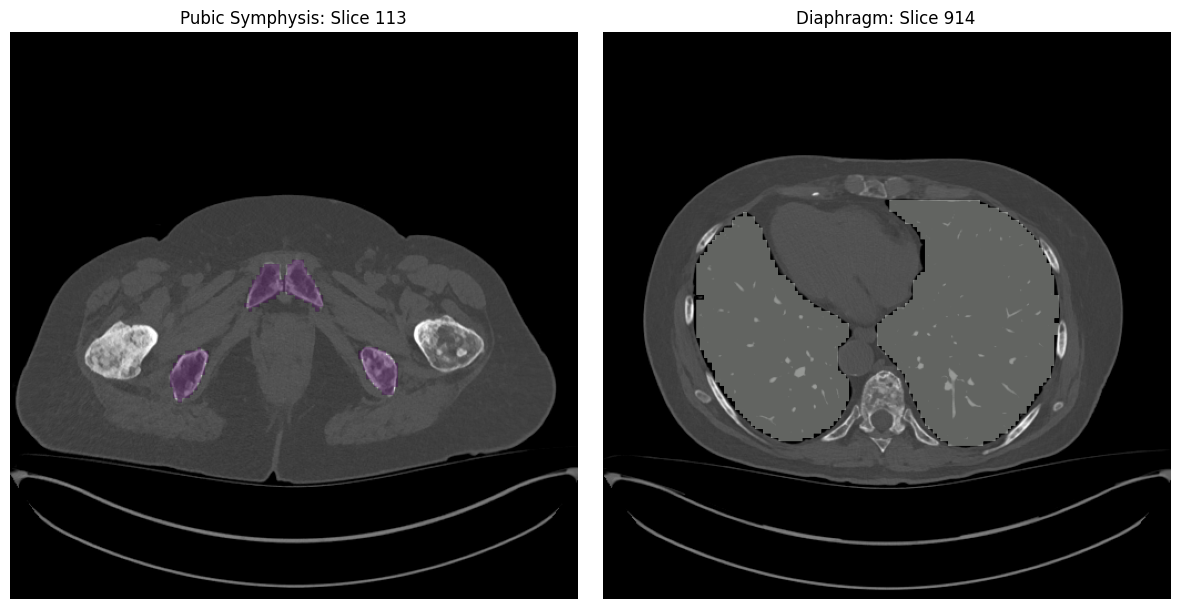

In [3]:
# Add this at the very top to ensure inline plotting
%matplotlib inline

import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os

# ── 1. Paths (assumes dicom_dir was defined above) ────────────────────────────
combo_f_pelvis = os.path.join(dicom_dir, "_seg_pelvis", "hips_combined.nii.gz")
combo_f_lung   = os.path.join(dicom_dir, "_seg_lung",  "lungs_combined.nii.gz")

# 🔁 pubic_idx is assumed to be defined in an earlier cell via nibabel logic

# ── 2. Load & re-orient CT to RAS ─────────────────────────────────────────────
reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
ct_raw = reader.Execute()

orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
ct_ras = orienter.Execute(ct_raw)
ct_np = sitk.GetArrayFromImage(ct_ras)

# ── 3. Resample pelvis mask to CT geometry ────────────────────────────────────
mask_itk_pelvis = sitk.ReadImage(combo_f_pelvis)
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_ras)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_np_pelvis = sitk.GetArrayFromImage(resampler.Execute(mask_itk_pelvis)).astype(bool)

# ── 4. Resample lung mask to CT geometry ──────────────────────────────────────
mask_itk_lung = sitk.ReadImage(combo_f_lung)
mask_np_lung = sitk.GetArrayFromImage(resampler.Execute(mask_itk_lung)).astype(bool)

# ── 5. Find diaphragm slice (most inferior lung slice) ────────────────────────
diaphragm_idx = int(np.where(mask_np_lung.any(axis=(1, 2)))[0][-1])

# ── 6. HU windowing function ──────────────────────────────────────────────────
def hu_window(arr, level=400, width=2000):
    lo, hi = level - width/2, level + width/2
    return ((np.clip(arr, lo, hi) - lo) / (hi - lo) * 255).astype(np.uint8)

# ── 7. Side-by-side verification plots ────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Pubic symphysis overlay
axs[0].imshow(hu_window(ct_np[pubic_idx]), cmap="gray", origin="lower")
axs[0].imshow(np.ma.masked_where(~mask_np_pelvis[pubic_idx], mask_np_pelvis[pubic_idx]),
              alpha=0.4, origin="lower")
axs[0].set_title(f"Pubic Symphysis: Slice {pubic_idx}")
axs[0].axis("off")

# Diaphragm overlay
axs[1].imshow(hu_window(ct_np[diaphragm_idx]), cmap="gray", origin="lower")
axs[1].imshow(np.ma.masked_where(~mask_np_lung[diaphragm_idx], mask_np_lung[diaphragm_idx]),
              alpha=0.4, origin="lower", cmap="Greens")
axs[1].set_title(f"Diaphragm: Slice {diaphragm_idx}")
axs[1].axis("off")

plt.tight_layout()
plt.show()